<a href="https://colab.research.google.com/github/milan98-jpg/Stage2_Deliverables/blob/main/Customer_Churn_Analysis_notebook.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Customer Churn Analysis Project (Telecommunications)

**Purpose:** End-to-end churn analysis aligned to the project charter deliverables: data audit + preprocessing, customer segmentation (K-Means), churn prediction using an **ANN-style model (MLP)**, and stakeholder-ready KPIs + outputs.



## 1) Imports and Display Setup
This cell imports all libraries used across data cleaning, EDA, clustering, and ANN modeling.



### 1.1 Core Libraries
This cell imports core data and plotting libraries used across the notebook.


In [12]:
# Core data libraries
import pandas as pd
import numpy as np

# Visualization
import matplotlib.pyplot as plt


### 1.2 Modeling Utilities
This cell imports model-selection, preprocessing, pipeline, and evaluation utilities for ANN and validation workflows.


In [13]:
# Model building and evaluation
from sklearn.model_selection import train_test_split, StratifiedKFold, cross_val_score
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.metrics import (
    classification_report,
    accuracy_score,
    roc_auc_score,
    RocCurveDisplay,
    ConfusionMatrixDisplay,
)
from sklearn.neural_network import MLPClassifier
from sklearn.calibration import CalibratedClassifierCV


### 1.3 Segmentation and Notebook Display
This cell imports clustering, dimensionality reduction, and display helpers used in segmentation outputs and diagnostics.


In [14]:
# Clustering and dimensionality reduction
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score
from sklearn.decomposition import PCA

# Notebook display helper
from IPython.display import display


## 2) Data Loading and Initial Audit
Load the raw dataset, inspect shape, and run an initial quality check.


In [15]:
# Load source dataset
DATA_PATH = r"/Dataset_ATS_v2.csv"
raw = pd.read_csv(DATA_PATH)

print("Shape:", raw.shape)
raw.head()


Shape: (7043, 10)


,gender,SeniorCitizen,Dependents,tenure,PhoneService,MultipleLines,InternetService,Contract,MonthlyCharges,Churn
0,Female,0,No,1,No,No,DSL,Month-to-month,25,Yes
1,Male,0,No,41,Yes,No,DSL,One year,25,No
2,Female,0,Yes,52,Yes,No,DSL,Month-to-month,19,No
3,Female,0,No,1,Yes,No,DSL,One year,76,Yes
4,Male,0,No,67,Yes,No,Fiber optic,Month-to-month,51,No


### 2.1 Data Profiling Details
This cell provides detailed profiling outputs for missing values, duplicate counts, and data types after loading the dataset.


In [16]:
# Create working copy and normalize column names
df = raw.copy()
df.columns = [c.strip() for c in df.columns]

print("Columns:", len(df.columns))
display(df.describe(include="all").T.head(20))

# Missing values overview
missing = df.isna().sum().sort_values(ascending=False)
missing = missing[missing > 0]
print()
print("Missing values (top):")
display(missing.head(20))

# Duplicate check
dup_count = df.duplicated().sum()
print()
print("Duplicate rows:", dup_count)

# Data type check
print()
print("Dtypes:")
display(df.dtypes)



Columns: 10


,count,unique,top,freq,mean,std,min,25%,50%,75%,max
gender,7043,2,Male,3555,NaN,NaN,NaN,NaN,NaN,NaN,NaN
SeniorCitizen,7043.0,NaN,NaN,NaN,0.162147,0.368612,0.0,0.0,0.0,0.0,1.0
Dependents,7043,2,No,4933,NaN,NaN,NaN,NaN,NaN,NaN,NaN
tenure,7043.0,NaN,NaN,NaN,32.371149,24.559481,0.0,9.0,29.0,55.0,72.0
PhoneService,7043,2,Yes,6361,NaN,NaN,NaN,NaN,NaN,NaN,NaN
MultipleLines,7043,2,No,4072,NaN,NaN,NaN,NaN,NaN,NaN,NaN
InternetService,7043,2,DSL,3947,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Contract,7043,3,Month-to-month,3875,NaN,NaN,NaN,NaN,NaN,NaN,NaN
MonthlyCharges,7043.0,NaN,NaN,NaN,64.758768,30.09165,18.0,36.0,70.0,90.0,119.0
Churn,7043,2,No,5174,NaN,NaN,NaN,NaN,NaN,NaN,NaN



Missing values (top):


,0



Duplicate rows: 302

Dtypes:


,0
gender,object
SeniorCitizen,int64
Dependents,object
tenure,int64
PhoneService,object
MultipleLines,object
InternetService,object
Contract,object
MonthlyCharges,int64
Churn,object


## 3) Data Cleaning and Feature Engineering
This section standardizes data types, encodes the target, handles missing/outliers, and produces a cleaned master file.


### 3.1 Identify Target Column
Automatically detect the churn target column name.


In [17]:
# Detect churn target using common naming patterns
target_candidates = [
    c for c in df.columns
    if c.lower() in {"churn", "churned", "is_churn", "customerchurn"}
]
if not target_candidates:
    raise ValueError("Could not find churn target column. Expected a column named like 'Churn'.")

TARGET = target_candidates[0]
print("Using TARGET column:", TARGET)


Using TARGET column: Churn


### 3.2 Normalize Numeric-Like Text and Remove Duplicates
Convert numeric-looking object columns and remove duplicate rows.


In [18]:
# Convert object columns that mostly contain numbers
for col in df.columns:
    if df[col].dtype == "object":
        sample = df[col].dropna().astype(str).head(50)
        if len(sample) and sample.str.match(r"^\s*-?\d+(\.\d+)?\s*$").mean() > 0.8:
            df[col] = pd.to_numeric(df[col].astype(str).str.strip(), errors="coerce")

# Common telecom cleanup for TotalCharges
if "TotalCharges" in df.columns and df["TotalCharges"].dtype == "object":
    df["TotalCharges"] = pd.to_numeric(df["TotalCharges"].astype(str).str.strip(), errors="coerce")

# Remove exact duplicates
before = len(df)
df = df.drop_duplicates().copy()
after = len(df)
print(f"Removed duplicates: {before - after}")


Removed duplicates: 302


### 3.3 Build Features and Binary Target
Split feature matrix and convert churn target to a reliable binary format.


### 3.3.1 Split Features and Target
This cell separates the selected target column from model features to create reusable inputs for cleaning, segmentation, and ANN modeling.


In [19]:
# Separate features and raw target
y_raw = df[TARGET].copy()
X = df.drop(columns=[TARGET]).copy()


### 3.3.2 Convert Target to Binary
This cell converts target labels into binary values using bool, numeric, and text-safe mapping logic with a fallback for uncommon two-class labels.


In [20]:
# Robust target conversion across bool/numeric/text labels
y_series = pd.Series(y_raw)
if pd.api.types.is_bool_dtype(y_series):
    y = y_series.astype(int)
elif pd.api.types.is_numeric_dtype(y_series):
    y = pd.to_numeric(y_series, errors="coerce")
    if y.isna().any():
        raise ValueError("Target column contains non-numeric values that could not be coerced.")
    y = y.astype(int)
else:
    mapped = y_series.astype(str).str.strip().str.lower().map({
        "yes": 1, "y": 1, "true": 1, "1": 1,
        "no": 0, "n": 0, "false": 0, "0": 0,
    })
    if mapped.isna().any():
        labels = y_series.dropna().astype(str).str.strip()
        value_counts = labels.value_counts()
        if len(value_counts) != 2:
            raise ValueError(f"Unexpected target values in '{TARGET}'. Expected binary labels, got: {list(value_counts.index)[:10]}")
        ordered = value_counts.index.tolist()
        fallback_map = {ordered[0]: 0, ordered[1]: 1}
        print(f"Warning: using fallback target mapping: {fallback_map}")
        y = labels.map(fallback_map).astype(int)
    else:
        y = mapped.astype(int)


### 3.4 Missing Values, Outlier Treatment, and Audit Outputs
Identify feature types, impute missing values, clip outliers, and save cleaned data + audit report.


### 3.4.1 Detect Column Types
This cell identifies numeric and categorical feature groups so the next preprocessing steps apply the right strategy by data type.


In [21]:
# Identify feature data types for targeted preprocessing
numeric_cols = [c for c in X.columns if pd.api.types.is_numeric_dtype(X[c])]
categorical_cols = [c for c in X.columns if c not in numeric_cols]
print("Numeric cols:", len(numeric_cols), "Categorical cols:", len(categorical_cols))


Numeric cols: 3 Categorical cols: 6


### 3.4.2 Fill Missing Values
This cell imputes missing values using median for numeric features and mode for categorical features to stabilize downstream modeling.


In [22]:
# Fill missing values using robust defaults by type
for c in numeric_cols:
    if X[c].isna().any():
        X[c] = X[c].fillna(X[c].median())
for c in categorical_cols:
    if X[c].isna().any():
        X[c] = X[c].fillna(X[c].mode(dropna=True)[0])


### 3.4.3 Cap Outliers and Audit
This cell caps numeric outliers with IQR fences, builds outlier summaries, and generates cleaned audit outputs for reporting and exports.


In [23]:
# Cap extreme numeric values using IQR fences
outlier_summary = []
for c in numeric_cols:
    q1 = X[c].quantile(0.25)
    q3 = X[c].quantile(0.75)
    iqr = q3 - q1
    if iqr == 0 or pd.isna(iqr):
        outlier_summary.append((c, 0, 0, 0))
        continue

    low = q1 - 1.5 * iqr
    high = q3 + 1.5 * iqr
    n_low = int((X[c] < low).sum())
    n_high = int((X[c] > high).sum())
    X[c] = X[c].clip(lower=low, upper=high)
    outlier_summary.append((c, n_low, n_high, n_low + n_high))

outlier_df = pd.DataFrame(outlier_summary, columns=["feature", "outliers_low", "outliers_high", "outliers_total"])


### 3.4.4 Build Cleaned Master and Audit
This cell saves the cleaned master dataset and compiles audit metrics and outlier summaries for reporting outputs.


In [24]:
cleaned_master = X.copy()
cleaned_master[TARGET] = y.values
cleaned_master.to_csv("cleaned_master_file.csv", index=False)

audit = {
    "rows": len(cleaned_master),
    "columns": len(cleaned_master.columns),
    "duplicates_removed": int(before - after),
    "missing_before_total": int(raw.isna().sum().sum()),
    "missing_after_total": int(cleaned_master.isna().sum().sum()),
    "outliers_treated_total": int(outlier_df["outliers_total"].sum()) if len(outlier_df) else 0,
}

print("Audit summary:", audit)
display(pd.DataFrame([audit]))
if len(outlier_df):
    display(outlier_df.sort_values("outliers_total", ascending=False))


Audit summary: {'rows': 6741, 'columns': 10, 'duplicates_removed': 302, 'missing_before_total': 0, 'missing_after_total': 0, 'outliers_treated_total': 0}


,rows,columns,duplicates_removed,missing_before_total,missing_after_total,outliers_treated_total
0,6741,10,302,0,0,0


,feature,outliers_low,outliers_high,outliers_total
0,SeniorCitizen,0,0,0
1,tenure,0,0,0
2,MonthlyCharges,0,0,0


## 4) Exploratory Data Analysis (EDA)
Analyze churn distribution and feature patterns.


Churn rate: 0.266 (26.6%)


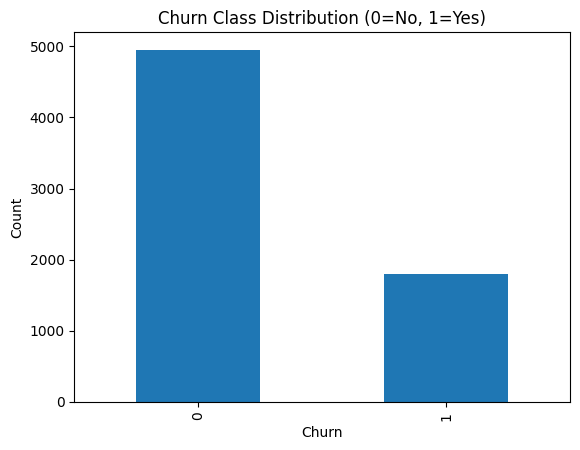

In [25]:
# Churn balance overview
churn_rate = y.mean()
print(f"Churn rate: {churn_rate:.3f} ({churn_rate * 100:.1f}%)")

plt.figure()
pd.Series(y).value_counts().sort_index().plot(kind="bar")
plt.title("Churn Class Distribution (0=No, 1=Yes)")
plt.xlabel("Churn")
plt.ylabel("Count")
plt.show()


### 4.1 Additional EDA Views
This cell explores feature distributions and churn behavior across key categorical features to support pattern discovery.


### 4.1.1 EDA Plot Inputs
This cell prepares numeric and categorical feature lists used by the EDA visuals and later cluster interpretation steps.


In [26]:
# Prepare numeric and categorical fields for EDA plots
plot_cols = numeric_cols[:6] if numeric_cols else []
common_cats = [
    c for c in ["Contract", "PaymentMethod", "InternetService", "TechSupport"]
    if c in X.columns
]


### 4.1.2 Numeric Distribution Charts
This cell plots numeric feature distributions in a two-column grid and hides unused subplot slots for cleaner layout.


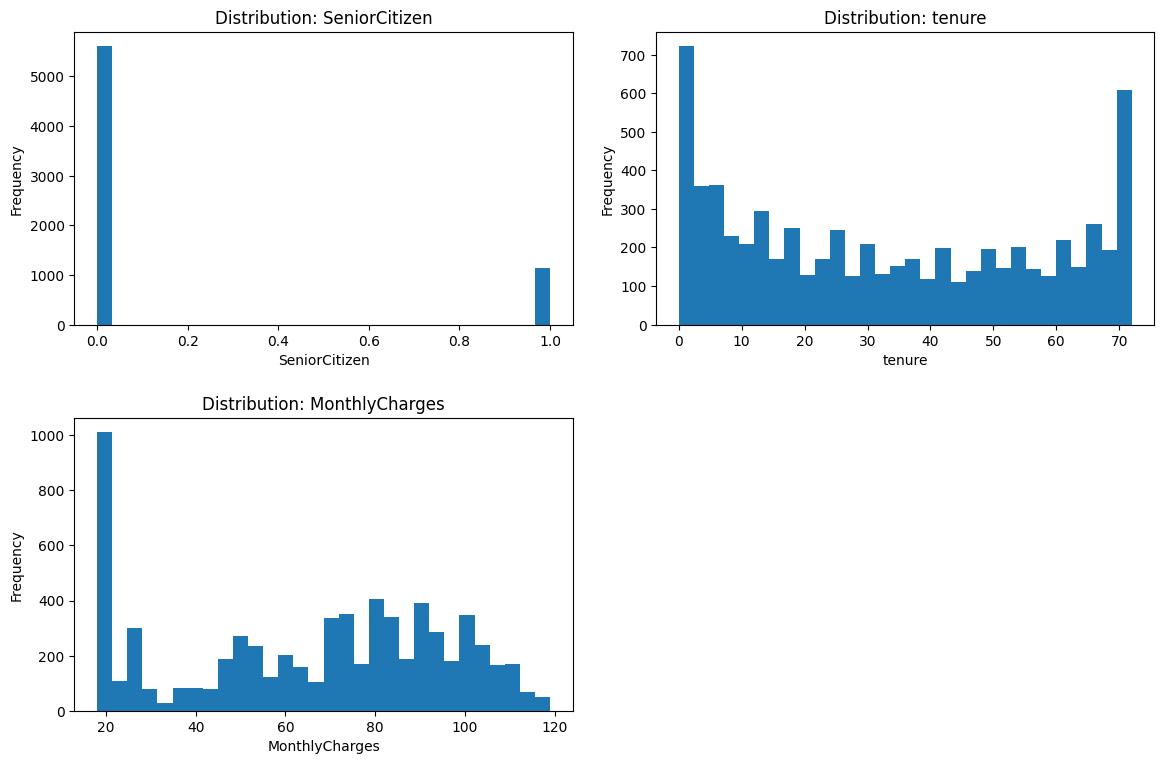

In [27]:
# Plot numeric distributions in a 2-column layout for quick comparison
if plot_cols:
    n = len(plot_cols)
    ncols = 2
    nrows = int(np.ceil(n / ncols))
    fig, axes = plt.subplots(nrows=nrows, ncols=ncols, figsize=(12, 4 * nrows))
    axes = np.array(axes).reshape(-1)

    for i, col in enumerate(plot_cols):
        axes[i].hist(X[col].dropna(), bins=30)
        axes[i].set_title(f"Distribution: {col}")
        axes[i].set_xlabel(col)
        axes[i].set_ylabel("Frequency")

    for j in range(len(plot_cols), len(axes)):
        axes[j].set_visible(False)

    plt.tight_layout(pad=2.0, w_pad=2.0, h_pad=2.0)
    plt.show()


### 4.1.3 Categorical Churn Rate Charts
This cell compares churn rates across key categorical fields in a two-column layout for quick business pattern detection.


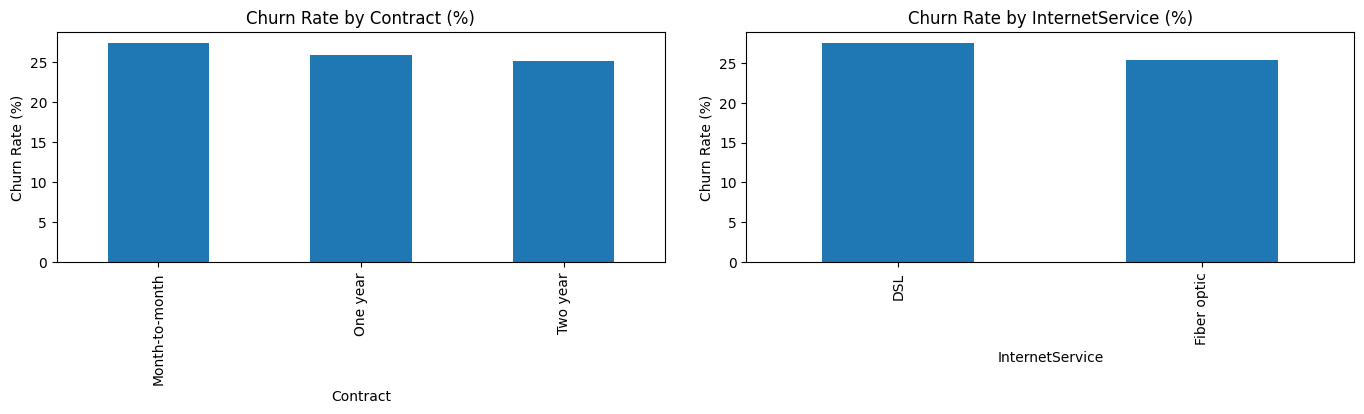

In [28]:
# Compare churn rates by category in a 2-column layout
if common_cats:
    n = len(common_cats)
    ncols = 2
    nrows = int(np.ceil(n / ncols))
    fig, axes = plt.subplots(nrows=nrows, ncols=ncols, figsize=(14, 4.5 * nrows))
    axes = np.array(axes).reshape(-1)

    for i, c in enumerate(common_cats):
        churn_rate = (pd.crosstab(X[c], y, normalize="index") * 100).get(1, pd.Series(dtype=float))
        churn_rate.sort_values(ascending=False).plot(kind="bar", ax=axes[i])
        axes[i].set_title(f"Churn Rate by {c} (%)")
        axes[i].set_xlabel(c)
        axes[i].set_ylabel("Churn Rate (%)")

    for j in range(len(common_cats), len(axes)):
        axes[j].set_visible(False)

    plt.tight_layout(pad=2.0, w_pad=2.5, h_pad=2.5)
    plt.show()


## 5) Customer Segmentation (K-Means)
Preprocess data for clustering, select optimal k, and profile segments.


### 5.0.1 Clustering Preprocess Pipeline
This cell builds preprocessing for clustering and transforms the feature matrix into clustering-ready input.


In [29]:
# Build preprocessing pipeline for clustering
preprocess = ColumnTransformer(
    transformers=[
        ("num", StandardScaler(), numeric_cols),
        ("cat", OneHotEncoder(handle_unknown="ignore"), categorical_cols),
    ],
    remainder="drop",
)

# Transform feature matrix
X_clust = preprocess.fit_transform(X)


### 5.0.2 Encoding and Scaling Artifacts
This cell creates encoding schema and scaled numeric preview outputs used in reporting and QA checks.


In [30]:
# Build encoding schema deliverable for categorical features
encoding_schema = pd.DataFrame(columns=["feature", "encoded_columns"])
if categorical_cols:
    ohe = preprocess.named_transformers_["cat"]
    mapping = []
    for cat, cats in zip(categorical_cols, ohe.categories_):
        mapping.append({
            "feature": cat,
            "encoded_columns": ", ".join([f"{cat}_{v}" for v in cats]),
        })
    encoding_schema = pd.DataFrame(mapping)

# Save scaled numeric preview deliverable
scaled_numeric_preview = pd.DataFrame(columns=numeric_cols)
if numeric_cols:
    scaler = preprocess.named_transformers_["num"]
    scaled_numeric_preview = pd.DataFrame(
        scaler.transform(X[numeric_cols]),
        columns=numeric_cols,
    ).head(10)


### 5.1 Cluster Count Selection
This cell evaluates multiple `k` values using elbow and silhouette methods to choose the optimal cluster count.


### 5.1.1 Evaluate Candidate K Values
This cell computes inertia and silhouette scores across candidate cluster counts for objective selection.


In [31]:
# Compare candidate k values using inertia + silhouette
ks = range(2, 11)
inertias = []
sil_scores = []

for k in ks:
    km = KMeans(n_clusters=k, random_state=42, n_init=10)
    labels = km.fit_predict(X_clust)
    inertias.append(km.inertia_)
    sil_scores.append(silhouette_score(X_clust, labels))


### 5.1.2 Visualize K Selection
This cell plots elbow and silhouette charts and prints the selected best cluster count.


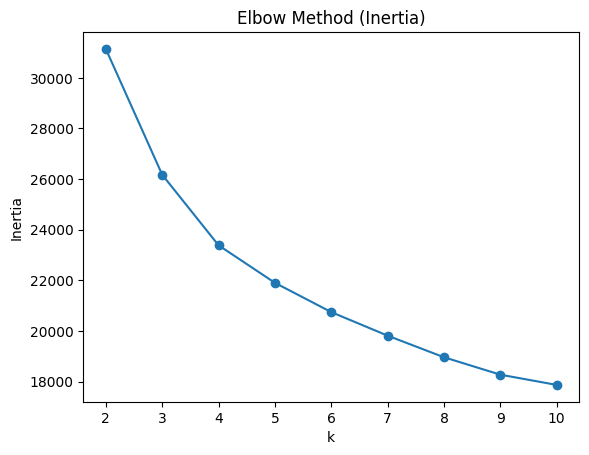

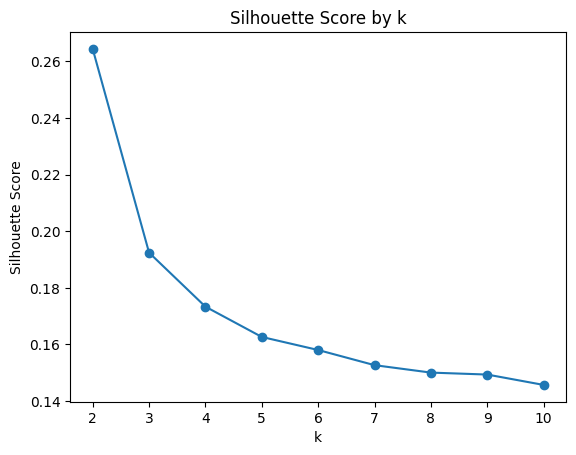

Best k (by silhouette): 2


In [32]:
# Elbow chart
plt.figure()
plt.plot(list(ks), inertias, marker="o")
plt.title("Elbow Method (Inertia)")
plt.xlabel("k")
plt.ylabel("Inertia")
plt.show()

# Silhouette chart
plt.figure()
plt.plot(list(ks), sil_scores, marker="o")
plt.title("Silhouette Score by k")
plt.xlabel("k")
plt.ylabel("Silhouette Score")
plt.show()

best_k = list(ks)[int(np.argmax(sil_scores))]
print("Best k (by silhouette):", best_k)


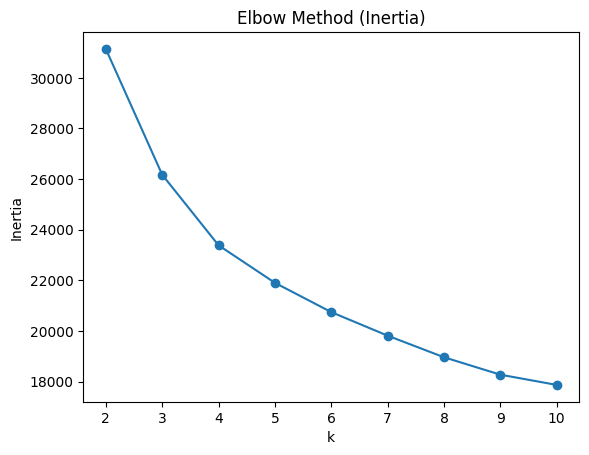

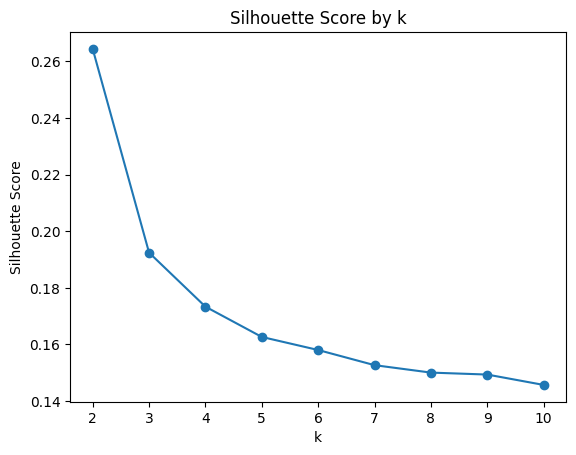

Best k (by silhouette): 2


In [33]:
# Elbow chart
plt.figure()
plt.plot(list(ks), inertias, marker="o")
plt.title("Elbow Method (Inertia)")
plt.xlabel("k")
plt.ylabel("Inertia")
plt.show()

# Silhouette chart
plt.figure()
plt.plot(list(ks), sil_scores, marker="o")
plt.title("Silhouette Score by k")
plt.xlabel("k")
plt.ylabel("Silhouette Score")
plt.show()

best_k = list(ks)[int(np.argmax(sil_scores))]
print("Best k (by silhouette):", best_k)


### 5.2 Final Segmentation Outputs
This cell trains the final K-Means model, builds segment profiles, and visualizes clusters using PCA.


### 5.2.1 Train Final Segmentation Model
This cell fits the final K-Means model and produces cluster labels for all records.


In [34]:
# Train final clustering model
kmeans = KMeans(n_clusters=best_k, random_state=42, n_init=10)
cluster_labels = kmeans.fit_predict(X_clust)


### 5.2.2 Attach Labels and Preview
This cell appends cluster labels and previews segmentation and preprocessing artifacts.


In [35]:
# Attach cluster results to cleaned data
segmented = cleaned_master.copy()
segmented["cluster"] = cluster_labels
segmented["churn_binary"] = y.values

display(segmented[["cluster", "churn_binary"]].head())
if not encoding_schema.empty:
    display(encoding_schema)
if not scaled_numeric_preview.empty:
    display(scaled_numeric_preview)


,cluster,churn_binary
0,0,1
1,0,0
2,0,0
3,0,1
4,0,0


,feature,encoded_columns
0,gender,"gender_Female, gender_Male"
1,Dependents,"Dependents_No, Dependents_Yes"
2,PhoneService,"PhoneService_No, PhoneService_Yes"
3,MultipleLines,"MultipleLines_No, MultipleLines_Yes"
4,InternetService,"InternetService_DSL, InternetService_Fiber optic"
5,Contract,"Contract_Month-to-month, Contract_One year, Co..."


,SeniorCitizen,tenure,MonthlyCharges
0,-0.448765,-1.312875,-1.376228
1,-0.448765,0.331038,-1.376228
2,-0.448765,0.783114,-1.578399
3,-0.448765,-1.312875,0.342225
4,-0.448765,1.399582,-0.500154
5,2.228337,1.440680,0.813957
6,-0.448765,-0.408722,0.375920
7,-0.448765,1.605071,0.207444
8,-0.448765,1.522875,1.285689
9,-0.448765,-1.312875,-1.578399


### 5.2.3 PCA Cluster Visualization
This cell projects clustering features into 2D space and visualizes cluster separation.


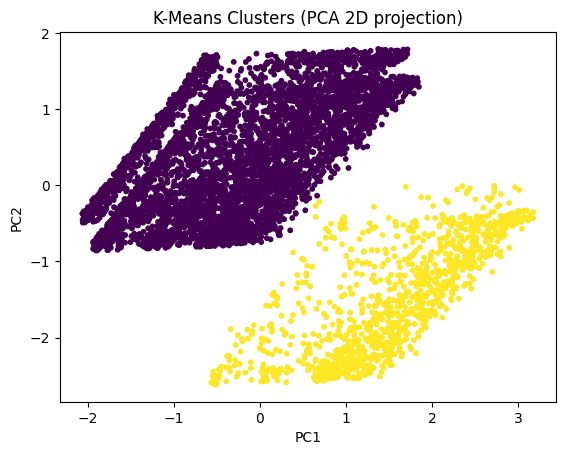

In [36]:
# PCA projection for 2D visualization
pca = PCA(n_components=2, random_state=42)
X_2d = pca.fit_transform(X_clust.toarray() if hasattr(X_clust, "toarray") else X_clust)

plt.figure()
plt.scatter(X_2d[:, 0], X_2d[:, 1], c=cluster_labels, s=10)
plt.title("K-Means Clusters (PCA 2D projection)")
plt.xlabel("PC1")
plt.ylabel("PC2")
plt.show()


### 5.2.4 Segment Profiles and Dominant Categories
This cell builds cluster profile tables and reports dominant category values for business interpretation.


In [37]:
# Segment-level profile summary
profile_num = segmented.groupby("cluster")[numeric_cols].mean() if numeric_cols else pd.DataFrame()
profile_churn = segmented.groupby("cluster")["churn_binary"].mean().rename("churn_rate")
profile_size = segmented.groupby("cluster").size().rename("customers")
profiles = pd.concat([profile_size, profile_churn, profile_num], axis=1).sort_index()

display(profiles)

# Dominant category per cluster for key columns
for c in common_cats:
    print("\nTop", c, "per cluster:")
    top = segmented.groupby("cluster")[c].agg(lambda s: s.value_counts().index[0])
    display(top)


,customers,churn_rate,SeniorCitizen,tenure,MonthlyCharges
cluster,,,,,
0,5611,0.236143,0.0,32.848512,63.032615
1,1130,0.412389,1.0,33.424779,79.800885



Top Contract per cluster:


,Contract
cluster,
0,Month-to-month
1,Month-to-month



Top InternetService per cluster:


,InternetService
cluster,
0,DSL
1,DSL
